In [132]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import os
import math
import random
from tqdm.notebook import tqdm as tqdm
from matplotlib.colors import ListedColormap
import matplotlib.patheffects as pe
import matplotlib.patches as mpatches

In [165]:
pickle_file = "../beta_zerooneeight.pth"

In [166]:
device="cpu" 

In [167]:
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

In [168]:
def sin(t):
    return np.sin(t)

def saw(t):
    return ( ((t-np.pi)/(2*np.pi))%1 - .5) *2

def square(t):
    return np.sign(np.sin(t))

def tri(t):
    sw = saw(t+np.pi/2)*2
    return sw * np.sign(sw)- 1

In [169]:
def create_waveforms(fn=sin, fs=512, duration=1024, period=440, phase=0, amplitude=1):
    period = np.array(period)
    period = np.reshape(period, (period.size, 1))

    phase = np.array(phase)
    phase = np.reshape(phase, (phase.size, 1))

    amplitude = np.array(amplitude)
    amplitude = np.reshape(amplitude, (amplitude.size, 1))

    t = (np.arange(0, duration, 1)/fs)[None,:]
    x = amplitude * fn(2*np.pi*(phase + t*period))
    return x, t

In [170]:
class VAE(torch.nn.Module):
    def __init__(self, input_dim=512, latent_dim=2, hidden_dims=[128, 64, 36]):
        super().__init__()

        self.encoder = torch.nn.Sequential(
            torch.nn.Linear(input_dim, hidden_dims[0]),
            torch.nn.Tanh(),
            torch.nn.Linear(hidden_dims[0], hidden_dims[1]),
            torch.nn.Tanh(),
            torch.nn.Linear(hidden_dims[1],hidden_dims[2]),
            torch.nn.Tanh(),
            
        )

        self.z_mean = torch.nn.Linear(hidden_dims[2], latent_dim)
        self.z_log_var = torch.nn.Linear(hidden_dims[2], latent_dim)


        self.decoder = torch.nn.Sequential(
            torch.nn.Linear(latent_dim, hidden_dims[2]),
            torch.nn.Tanh(),
            torch.nn.Linear(hidden_dims[2], hidden_dims[1]),
            torch.nn.Tanh(),
            torch.nn.Linear(hidden_dims[1], hidden_dims[0]),
            torch.nn.Tanh(),
            torch.nn.Linear(hidden_dims[0], input_dim),
        )


    def reparameterize(self, z_mu, z_log_var):
        device = z_mu.device
        # Sampling the eps from the standard multivariate normal distribution in each forward pass
        eps = torch.randn(z_mu.size(0), z_mu.size(1)).to(device)
        # reparameterized_mean = mean_vector + random noise(eps) + log variance
        z = z_mu + eps * torch.exp(z_log_var / 2.0)
        return z

    def forward(self, x):
        x = self.encoder(x)
        z_mean, z_log_var = self.z_mean(x), self.z_log_var(x)
        encoded = self.reparameterize(z_mean, z_log_var)
        decoded = self.decoder(encoded)
        return encoded,z_mean,z_log_var,decoded

In [171]:
input_length = 256

np.random.seed(0)
n_samples_train = 100000

periods_train = np.random.uniform(200, 2000, n_samples_train)

x_sin, _ = create_waveforms(fn=sin, fs=22050, duration=input_length, phase=0, period=periods_train[0*n_samples_train//4:1*n_samples_train//4], amplitude=1)
x_saw, _ = create_waveforms(fn=saw, fs=22050, duration=input_length, phase=0, period=periods_train[1*n_samples_train//4:2*n_samples_train//4], amplitude=1)
x_tri, _ = create_waveforms(fn=tri, fs=22050, duration=input_length, phase=0, period=periods_train[2*n_samples_train//4:3*n_samples_train//4], amplitude=1)
x_square, _ = create_waveforms(fn=square, fs=22050, duration=input_length, phase=0, period=periods_train[3*n_samples_train//4:4*n_samples_train//4], amplitude=1)

x_train = torch.tensor(np.concatenate([x_sin, x_saw, x_tri, x_square], axis=0), dtype=torch.float32)
shapes_train = np.arange(n_samples_train) // (n_samples_train//4)

In [172]:
autoencoder = VAE(input_dim=input_length, latent_dim=2, hidden_dims=[256,128,64])
autoencoder.load_state_dict(torch.load(pickle_file))

<All keys matched successfully>

In [173]:
shuffle_indices = np.random.permutation(np.arange(n_samples_train))

x_train_shuffle = x_train[shuffle_indices]
shapes_train_shuffle = shapes_train[shuffle_indices]
periods_train_shuffle = periods_train[shuffle_indices]

In [174]:
x = autoencoder.encoder(x_train_shuffle)
z_mean, z_log_var = autoencoder.z_mean(x), autoencoder.z_log_var(x)
encoded_orig = autoencoder.reparameterize(z_mean, z_log_var).detach().numpy()

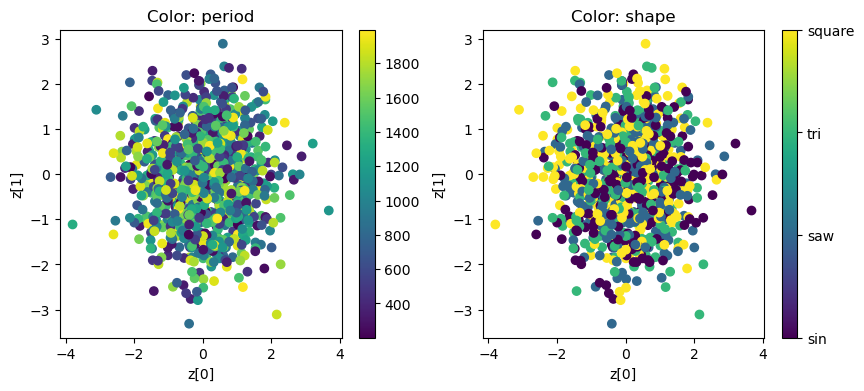

In [175]:
n_plot=1000

fig, ax = plt.subplots(1,2, figsize=(10,4))

im0 = ax[0].scatter(encoded_orig[:n_plot,0], encoded_orig[:n_plot,1], c=periods_train_shuffle[:n_plot])
im1 = ax[1].scatter(encoded_orig[:n_plot,0], encoded_orig[:n_plot,1], c=shapes_train_shuffle[:n_plot])

ax[0].set_xlabel("z[0]")
ax[0].set_ylabel("z[1]")
ax[0].set_title("Color: period")

ax[1].set_xlabel("z[0]")
ax[1].set_ylabel("z[1]")
ax[1].set_title("Color: shape")

plt.colorbar(im0, ax=ax[0])
cbar = plt.colorbar(im1, ax=ax[1], ticks=[0, 1, 2, 3])

cbar.ax.set_yticklabels(["sin", "saw", "tri", "square"])

plt.show()

In [176]:
x1, _ = create_waveforms(fn=sin, fs=22050, duration=input_length, phase=0, period=200, amplitude=1)
x2, _ = create_waveforms(fn=square, fs=22050, duration=input_length, phase=0, period=300, amplitude=1)
# x3, _ = create_waveforms(fn=sin, fs=22050, duration=input_length, phase=0, period=550, amplitude=1)
# x4, _ = create_waveforms(fn=sin, fs=22050, duration=input_length, phase=0, period=575, amplitude=1)
# x5, _ = create_waveforms(fn=sin, fs=22050, duration=input_length, phase=0, period=600, amplitude=1)
# waveforms = [x1,x2,x3,x4,x5]

In [177]:
def linear_interpolate_waveforms(x1, x2, lambda_val):
    interpolated_waveforms = []
    for t in np.linspace(0, 1, lambda_val):
        interpolated_waveform = (1 - t) * x1 + t * x2
        interpolated_waveforms.append(interpolated_waveform)
    return interpolated_waveforms

In [178]:
z1 = autoencoder.encoder(torch.Tensor(x1))
z2 = autoencoder.encoder(torch.Tensor(x2))

In [179]:
lambda_val = 5
interpolated_original_waveforms = linear_interpolate_waveforms(x1, x2, lambda_val)

In [180]:
# interpolated_enocoded_waveforms = linear_interpolate_waveforms(z1, z2, lambda_val)

In [181]:
encoded_list = []
waves = [z1,z2]
for wav in waves:
    z_mean, z_log_var = autoencoder.z_mean(wav), autoencoder.z_log_var(wav)
    encoded = autoencoder.reparameterize(z_mean, z_log_var)
    encoded_list.append(encoded.detach().numpy())

In [182]:
encoded_list

[array([[-1.3189781 ,  0.60550636]], dtype=float32),
 array([[-0.56442934, -1.208487  ]], dtype=float32)]

In [183]:
decoded_wav = []
interpolated_enocoded_waveforms = linear_interpolate_waveforms(encoded_list[0], encoded_list[1], lambda_val)
for wav in interpolated_enocoded_waveforms:
    decoded = autoencoder.decoder(torch.Tensor(wav))
    decoded_wav.append(decoded)

In [184]:
decoded_wav

[tensor([[ 7.1759e-05,  4.0072e-01,  5.3934e-01,  6.5424e-01,  7.0754e-01,
           7.0897e-01,  5.8680e-01,  3.8798e-01,  2.2002e-01,  8.8642e-02,
           2.7777e-03, -4.4123e-02, -1.1123e-02,  4.1488e-02,  9.9061e-02,
           1.4957e-01,  1.8264e-01,  1.7054e-01,  1.1475e-01,  5.7533e-02,
           1.4192e-03, -3.6493e-02, -5.8974e-02, -4.1468e-02, -1.4486e-02,
           1.9007e-02,  4.9945e-02,  7.3670e-02,  6.9235e-02,  3.7355e-02,
           3.1491e-03, -3.0603e-02, -5.6564e-02, -7.4649e-02, -6.5424e-02,
          -4.6349e-02, -2.1476e-02,  3.3880e-03,  2.1878e-02,  2.2876e-02,
           1.3117e-03, -2.1199e-02, -4.6053e-02, -6.1937e-02, -7.3082e-02,
          -6.5203e-02, -5.3351e-02, -3.4081e-02, -1.3834e-02, -1.1728e-03,
          -6.4282e-04, -1.6204e-02, -3.5494e-02, -5.3242e-02, -6.6618e-02,
          -7.3541e-02, -6.3185e-02, -4.9795e-02, -3.3139e-02, -1.5686e-02,
           6.8155e-06,  3.5737e-03, -5.7178e-03, -2.1574e-02, -3.4314e-02,
          -4.4887e-02, -5

In [185]:
# encoded_list = []
# decoded_wav = []
# for wav in interpolated_enocoded_waveforms:
#     z_mean, z_log_var = autoencoder.z_mean(wav), autoencoder.z_log_var(wav)
#     encoded = autoencoder.reparameterize(z_mean, z_log_var)
#     decoded = autoencoder.decoder(encoded)
#     encoded_list.append(encoded.detach().numpy())
#     decoded_wav.append(decoded)

In [186]:
# mse_np(x1.flatten(),decoded_wav[0].detach().numpy().flatten())

In [187]:
from scipy.spatial import distance
mse_list = []
cosine_list = []
def mse_np(arr1, arr2):
    """Calculate MSE between two numpy arrays."""
    return np.mean((arr1 - arr2) ** 2)

def average_mse(np_list, torch_list):
    """Calculate the average MSE between a list of numpy arrays and a list of torch tensors."""
    total_mse = 0
    total_cosine = 0
    n = len(np_list)
    
    for np_array, torch_tensor in zip(np_list, torch_list):
        # Convert the torch tensor to numpy (detach if it requires gradients)
        torch_array = torch_tensor.detach().numpy() if torch_tensor.requires_grad else torch_tensor.numpy()
        
        # Compute MSE between numpy array and converted torch array
        mse_value = mse_np(np_array, torch_array)
        cosine_value = distance.cosine(np_array.flatten(), torch_array.flatten())
        mse_list.append(mse_value)
        cosine_list.append(cosine_value)
        total_mse += mse_value
        total_cosine +=cosine_value
    
    # Return the average MSE
    return np.round(total_mse / n,2),np.round(total_cosine / n,2)


avg_mse = average_mse(interpolated_original_waveforms, decoded_wav)

In [188]:
encoded_list

[array([[-1.3189781 ,  0.60550636]], dtype=float32),
 array([[-0.56442934, -1.208487  ]], dtype=float32)]

In [189]:
# for i, wave in enumerate(decoded_wav):
#     plt.figure(figsize=(10, 2))
#     plt.plot(wave[0].detach().numpy(),color='c', lw=1)
#     plt.axis("off")
#     plt.show()

In [190]:
# cmap = plt.cm.viridis  # You can choose a different colormap if desired

# # Plot the embedding space with a better color map and transparency
# plt.figure(figsize=(10, 8))
# scatter = plt.scatter(encoded_orig[:n_plot, 0], encoded_orig[:n_plot, 1], c=shapes_train_shuffle[:n_plot], 
#                       cmap=cmap, alpha=0.7, edgecolors='w', s=80, label='Data Points')

# # Label the axes and title with larger font size
# plt.xlabel("z[0]", fontsize=14)
# plt.ylabel("z[1]", fontsize=14)
# plt.title("Latent Space with Trajectory Overlay", fontsize=16)

# # Add a color bar with label
# cbar = plt.colorbar(scatter)
# cbar.set_label('Period', fontsize=14)

# # Convert list of arrays into a single 2D array for the trajectory
# trajectory_points = np.concatenate(encoded_list, axis=0)
# x_coords = trajectory_points[:, 0]
# y_coords = trajectory_points[:, 1]

# # Plot the trajectory and add it to the legend
# for i in range(len(x_coords) - 1):
#     plt.arrow(x_coords[i], y_coords[i], x_coords[i+1] - x_coords[i], y_coords[i+1] - y_coords[i], 
#               shape='full', lw=0, length_includes_head=True, head_width=0.7, color='red')

# # Add annotations at the start and end of the trajectory
# plt.text(x_coords[0], y_coords[0], 'Start', fontsize=14, ha='right', color='white', fontweight='bold', 
#          path_effects=[pe.withStroke(linewidth=3, foreground='black')])
# plt.text(x_coords[-1], y_coords[-1], 'End', fontsize=14, ha='right', color='white', fontweight='bold', 
#          path_effects=[pe.withStroke(linewidth=3, foreground='black')])

# # Add grid lines for better readability
# plt.grid(True, linestyle='--', alpha=0.5)

# # Add a legend entry for the trajectory overlay
# plt.plot([], [], 'r', label='Trajectory', lw=2, marker='o')

# # Improve legend with larger font size
# plt.legend(fontsize=14, loc='upper right')

# # Show the plot
# plt.show()

In [191]:
# cmap = plt.cm.viridis  # You can choose a different colormap if desired

# # Create the figure with a playful size
# plt.figure(figsize=(10,7))
# scatter = plt.scatter(encoded_orig[:n_plot, 0], encoded_orig[:n_plot, 1], 
#                       c=periods_train_shuffle[:n_plot], cmap=cmap, alpha=0.8, 
#                       edgecolors='k', s=100, marker='o')

# # Label the axes and title with a friendly font size
# plt.xlabel("Latent Dimension 1", fontsize=16, fontweight='bold')
# plt.ylabel("Latent Dimension 2", fontsize=16, fontweight='bold')
# plt.title("Latent Space with Trajectory Overlay", fontsize=18, fontweight='bold')

# # Add a color bar with a cute label
# cbar = plt.colorbar(scatter)
# cbar.set_label('Period (frequency)', fontsize=16, fontweight='bold')

# # Convert list of arrays into a single 2D array for the trajectory
# trajectory_points = np.concatenate(encoded_list, axis=0)
# x_coords = trajectory_points[:, 0]
# y_coords = trajectory_points[:, 1]

# # Draw the trajectory with cute arrows
# for i in range(len(x_coords) - 1):
#     plt.arrow(x_coords[i], y_coords[i], x_coords[i+1] - x_coords[i], y_coords[i+1] - y_coords[i], 
#               shape='full', lw=0, length_includes_head=True, head_width=0.8, color='coral', alpha=0.8)

# # Add cute annotations at the start and end of the trajectory
# plt.text(x_coords[0], y_coords[0], 'Start', fontsize=16, ha='left', color='white', 
#          fontweight='bold', 
#          path_effects=[pe.withStroke(linewidth=4, foreground='black')])
# plt.text(x_coords[-1], y_coords[-1], 'End', fontsize=16, ha='right', color='white', 
#          fontweight='bold', 
#          path_effects=[pe.withStroke(linewidth=4, foreground='black')])

# # Manually create a legend entry for the trajectory path
# coral_patch = mpatches.Patch(color='coral', label='Trajectory Path')

# # Improve legend with a larger font size and playful location
# plt.legend(handles=[coral_patch], fontsize=16, loc='best', edgecolor="black")

# # Show the plot with a friendly touch
# plt.tight_layout()
# plt.show()

In [192]:
# cmap = plt.cm.viridis  # You can choose a different colormap if desired

# # Number of subplots, assuming one waveform per interpolation step
# n_interpolations = len(decoded_wav)

# # Create a figure with subplots: Larger height ratio for latent space plot
# fig, axs = plt.subplots(n_interpolations + 1, 1, 
#                         figsize=(12, 2 * (n_interpolations + 2)), 
#                         gridspec_kw={'height_ratios': [3] + [1] * n_interpolations})

# # Latent space trajectory plot
# scatter = axs[0].scatter(encoded_orig[:n_plot, 0], encoded_orig[:n_plot, 1], 
#                          c=periods_train_shuffle[:n_plot], cmap=cmap, alpha=0.8, 
#                          edgecolors='k', s=100, marker='o')

# # Label the axes and title with a friendly font size
# axs[0].set_xlabel("Latent Dimension 1", fontsize=16, fontweight='bold')
# axs[0].set_ylabel("Latent Dimension 2", fontsize=16, fontweight='bold')
# axs[0].set_title("Latent Space with Trajectory Overlay", fontsize=18, fontweight='bold')

# # Add a color bar with a cute label
# cbar = fig.colorbar(scatter, ax=axs[0])
# cbar.set_label('Period (Time)', fontsize=16, fontweight='bold')

# # Convert list of arrays into a single 2D array for the trajectory
# trajectory_points = np.concatenate(encoded_list, axis=0)
# x_coords = trajectory_points[:, 0]
# y_coords = trajectory_points[:, 1]

# # Draw the trajectory with arrows
# for i in range(len(x_coords) - 1):
#     axs[0].arrow(x_coords[i], y_coords[i], x_coords[i+1] - x_coords[i], y_coords[i+1] - y_coords[i], 
#                  shape='full', lw=0, length_includes_head=True, head_width=0.4, color='coral', alpha=0.8)

# # Add annotations at the start and end of the trajectory
# axs[0].text(x_coords[0], y_coords[0], 'Start', fontsize=16, ha='left', color='white', 
#             fontweight='bold', 
#             path_effects=[pe.withStroke(linewidth=4, foreground='black')])
# axs[0].text(x_coords[-1], y_coords[-1], 'End', fontsize=16, ha='right', color='white', 
#             fontweight='bold', 
#             path_effects=[pe.withStroke(linewidth=4, foreground='black')])

# # Manually create a legend entry for the trajectory path
# coral_patch = mpatches.Patch(color='coral', label='Trajectory Path')

# # Improve legend with a larger font size and playful location
# axs[0].legend(handles=[coral_patch], fontsize=16, loc='best', edgecolor="black")

# # Plot the waveforms corresponding to the interpolations
# for i, wave in enumerate(decoded_wav):
#     axs[i + 1].plot(wave[0].detach().numpy())
#     axs[i + 1].set_title(f'Interpolated Waveform {i}', fontsize=14)
#     axs[i + 1].set_xlabel('Time')
#     axs[i + 1].set_ylabel('Amplitude')

# # Adjust layout to give more space to titles and improve spacing
# plt.subplots_adjust(hspace=0.5)
# plt.tight_layout()

# # Show the combined figure
# plt.show()

In [193]:
# cmap = plt.cm.viridis  # You can choose a different colormap if desired

# # Create the figure with a playful size
# plt.figure(figsize=(10, 7))
# scatter = plt.scatter(encoded_orig[:n_plot, 0], encoded_orig[:n_plot, 1], 
#                       c=periods_train_shuffle[:n_plot], cmap=cmap, alpha=0.8, 
#                       edgecolors='k', s=100, marker='o')

# # Label the axes and title with a friendly font size
# plt.xlabel("Latent Dimension 1", fontsize=16, fontweight='bold')
# plt.ylabel("Latent Dimension 2", fontsize=16, fontweight='bold')
# plt.title("Latent Space with Trajectory Overlay", fontsize=18, fontweight='bold')

# # Add a color bar with a cute label
# cbar = plt.colorbar(scatter)
# cbar.set_label('Period (frequency)', fontsize=16, fontweight='bold')

# # Convert list of arrays into a single 2D array for the trajectory
# trajectory_points = np.concatenate(encoded_list, axis=0)
# x_coords = trajectory_points[:, 0]
# y_coords = trajectory_points[:, 1]

# # Label each trajectory point with a number, change color of the numbers (e.g., 'coral')
# for i in range(len(x_coords)):
#     plt.text(x_coords[i], y_coords[i], str(i + 1), fontsize=14, color='coral', fontweight='bold', 
#              ha='center', path_effects=[pe.withStroke(linewidth=3, foreground='black')])

# # # Add cute annotations at the start and end of the trajectory
# # plt.text(x_coords[0], y_coords[0], 'Start', fontsize=16, ha='left', color='coral', 
# #          fontweight='bold', path_effects=[pe.withStroke(linewidth=4, foreground='black')])
# # plt.text(x_coords[-1], y_coords[-1], 'End', fontsize=16, ha='right', color='coral', 
# #          fontweight='bold', path_effects=[pe.withStroke(linewidth=4, foreground='black')])

# # Remove the legend call since no labeled elements are left to include
# # plt.legend(fontsize=16, loc='best', edgecolor="black")  # Removed

# # Show the plot with a friendly touch
# plt.tight_layout()
# plt.show()


In [194]:
# import matplotlib.pyplot as plt
# import numpy as np
# import matplotlib.gridspec as gridspec
# import matplotlib.patheffects as pe

# # Define the number of waveforms to plot
# n_waves = len(decoded_wav)  # You can limit this if needed
# # Create a figure with GridSpec for a flexible layout
# fig = plt.figure(figsize=(8, 5))  # Increase height based on the number of waveforms

# # GridSpec: Create a grid with 2 columns. The latent plot will take the first column, waveforms take the second column
# gs = gridspec.GridSpec(n_waves + 1, 2, width_ratios=[2, 1], height_ratios=[1] * (n_waves + 1))

# # --- Plot 1: Latent Space with Trajectory Overlay (Left side) ---
# ax_latent = plt.subplot(gs[:, 0])  # Left side will span all rows in the first column
# cmap = plt.cm.viridis  # Colormap for the latent space

# scatter = ax_latent.scatter(encoded_orig[:n_plot, 0], encoded_orig[:n_plot, 1], 
#                             c=shapes_train_shuffle[:n_plot], cmap=cmap, alpha=0.8, 
#                             edgecolors='k', s=100, marker='o')

# # Label the axes and title for the latent space plot
# # ax_latent.set_xlabel('')
# # ax_latent.set_ylabel("")
# # ax_latent.set_title(f'Average MSE: {round(np.mean(mse_list),2):.4f},Average CD: {round(np.mean(cosine_list),2):.4f}', fontsize=18, fontweight='bold')
# ax_latent.axis('off')
# # Trajectory points in latent space
# trajectory_points = np.concatenate(interpolated_enocoded_waveforms, axis=0)
# x_coords = trajectory_points[:, 0]
# y_coords = trajectory_points[:, 1]

# # Label each trajectory point with numbers (e.g., 'coral')
# for i in range(len(x_coords)):
#     ax_latent.text(x_coords[i], y_coords[i], str(i + 1), fontsize=14, color='coral', fontweight='bold', 
#                   ha='center', path_effects=[pe.withStroke(linewidth=3, foreground='black')])

# # Annotate a specific value in the top-right corner (e.g., average MSE or any other metric)
#   # Replace this with the value you want to annotate
# # ax_latent.text(1.0, 1.05, f'Average MSE: {avg_mse:.4f}', 
# #                transform=ax_latent.transAxes, fontsize=14, fontweight='bold',
# #                ha='right', va='bottom')

# # --- Plot 2: Waveforms (Stacked on the right side) ---
# for i, wave in enumerate(decoded_wav):
#     ax_wave = plt.subplot(gs[i + 1, 1])  # Place waveforms in the second column, stacked vertically
#     ax_wave.plot(wave[0].detach().numpy(), color='orange', lw=2, label='Generated', zorder=3)

#     # Plot the 'Original' waveforms (lighter)
#     ax_wave.plot(x1[0], color='green', lw=0.7, alpha=0.4, label='Original x1', zorder=1)
#     ax_wave.plot(x2[0], color='blue', lw=0.7, alpha=0.4, label='Original x1', zorder=1)

#     # Turn off axis for cleaner look
#     ax_wave.axis("off")
#     # ax_wave.set_title(f"{i+1} : MSE({np.round(mse_list[i],2)}),cosine({np.round(cosine_list[i],2)})",color="coral",fontweight="bold")

# # Adjust layout for better spacing
# plt.tight_layout()
# plt.savefig("zeroeight_interpolation.png")
# plt.show()


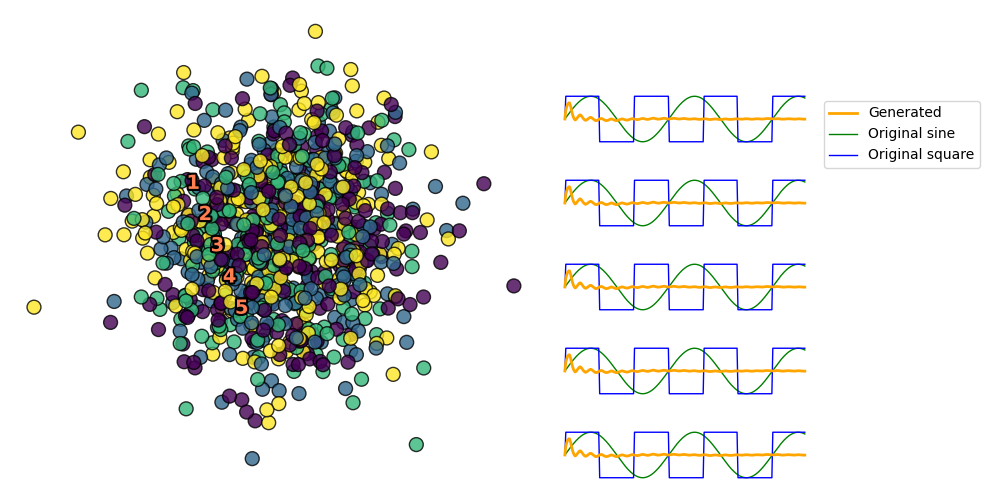

In [195]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.gridspec as gridspec
import matplotlib.patheffects as pe

# Define the number of waveforms to plot
n_waves = len(decoded_wav)  # You can limit this if needed
# Create a figure with GridSpec for a flexible layout
fig = plt.figure(figsize=(10, 5))  # Increase height based on the number of waveforms

# GridSpec: Create a grid with 2 columns. The latent plot will take the first column, waveforms take the second column
gs = gridspec.GridSpec(n_waves + 1, 2, width_ratios=[2, 1], height_ratios=[1] * (n_waves + 1))

# --- Plot 1: Latent Space with Trajectory Overlay (Left side) ---
ax_latent = plt.subplot(gs[:, 0])  # Left side will span all rows in the first column
cmap = plt.cm.viridis  # Colormap for the latent space

scatter = ax_latent.scatter(encoded_orig[:n_plot, 0], encoded_orig[:n_plot, 1], 
                            c=shapes_train_shuffle[:n_plot], cmap=cmap, alpha=0.8, 
                            edgecolors='k', s=100, marker='o')

# Remove axis for cleaner look
ax_latent.axis('off')

# Trajectory points in latent space
trajectory_points = np.concatenate(interpolated_enocoded_waveforms, axis=0)
x_coords = trajectory_points[:, 0]
y_coords = trajectory_points[:, 1]

# Label each trajectory point with numbers (e.g., 'coral')
for i in range(len(x_coords)):
    ax_latent.text(x_coords[i], y_coords[i], str(i + 1), fontsize=14, color='coral', fontweight='bold', 
                  ha='center', path_effects=[pe.withStroke(linewidth=3, foreground='black')])

# --- Plot 2: Waveforms (Stacked on the right side) ---
for i, wave in enumerate(decoded_wav):
    ax_wave = plt.subplot(gs[i + 1, 1])  # Place waveforms in the second column, stacked vertically
    ax_wave.plot(wave[0].detach().numpy(), color='orange', lw=2, label='Generated', zorder=3)

    # Plot the 'Original' waveforms (lighter)
    ax_wave.plot(x1[0], color='green', lw=1, label='Original sine', zorder=1)
    ax_wave.plot(x2[0], color='blue', lw=1, label='Original square', zorder=1)

    # Turn off axis for cleaner look
    ax_wave.axis("off")
    
    # Add the legend only to the first plot
    if i == 0:
        ax_wave.legend(loc='upper left', bbox_to_anchor=(1, 1))  # Move legend outside of the first plot

# Adjust layout for better spacing
plt.tight_layout()
plt.savefig("zerotwoshape_interpolation.png")
plt.show()


In [196]:
from tqdm import tqdm  # Import tqdm for the progress bar
import numpy as np

# Initialize lists to store the results for each interval
mse_values = []
cosine_values = []
waveform_shapes = [sin, tri, square, saw]
# Set the interval for periods (e.g., 200 to 1000 in steps of 100)
period_intervals = [(i, i + 100) for i in range(200, 1000, 100)]

# Number of runs for each interval
num_runs = 100

# Iterate over each period interval
for start_period, end_period in period_intervals:
    interval_mse_values = []  # MSE values for this interval
    interval_cosine_values = []  # Cosine similarity values for this interval

    # Run the experiment for `num_runs` iterations
    for run in tqdm(range(num_runs), desc=f"Processing period {start_period} to {end_period}", unit="run"):
        # Step 1: Generate waveforms for the given period interval
        periods = np.linspace(start_period, end_period, 5)  # Generate 5 equally spaced periods in the range
        waveforms = [create_waveforms(fn=sin, fs=22050, duration=input_length, phase=0, period=p, amplitude=1)[0] for p in periods]

        # Step 2: Interpolate between the first and last waveform
        z1 = autoencoder.encoder(torch.Tensor(waveforms[0]))
        z5 = autoencoder.encoder(torch.Tensor(waveforms[-1]))
        
        lambda_val = 5  # Interpolation step size
        encoded_list = []
        waves = [z1,z5]
        for wav in waves:
            z_mean, z_log_var = autoencoder.z_mean(wav), autoencoder.z_log_var(wav)
            encoded = autoencoder.reparameterize(z_mean, z_log_var)
            encoded_list.append(encoded.detach().numpy())

        # Step 3: Encode, decode, and calculate MSE for interpolated waveforms
        decoded_wav = []
        interpolated_enocoded_waveforms = linear_interpolate_waveforms(encoded_list[0], encoded_list[1], lambda_val)
        for wav in interpolated_enocoded_waveforms:
            decoded = autoencoder.decoder(torch.Tensor(wav))
            decoded_wav.append(decoded)
        # Step 4: Calculate average MSE and cosine similarity for this run
        # avg_mse = average_mse(interpolated_original_waveforms, decoded_wav)
        # Step 5: Store the average MSE and cosine similarity for this run
        mse,cosi = average_mse(interpolated_original_waveforms, decoded_wav)
        interval_mse_values.append(mse)
        interval_cosine_values.append(cosi)

    # After completing runs for the current interval, calculate and store the average MSE and cosine similarity
    mse_values.append(np.mean(interval_mse_values))
    cosine_values.append(np.mean(interval_cosine_values))

# After all intervals, calculate overall averages
overall_avg_mse = np.mean(mse_values)
overall_avg_cosine = np.mean(cosine_values)

# Print the results
print(f"Overall average MSE after {num_runs} runs across all intervals: {overall_avg_mse}")
print(f"Overall average cosine similarity after {num_runs} runs across all intervals: {overall_avg_cosine}")
print(f"Minimum MSE: {min(mse_values)}")
print(f"Minimum cosine similarity: {min(cosine_values)}")


Processing period 900 to 1000: 100%|███████████████████████████████████████████████| 100/100 [00:00<00:00, 373.18run/s]

Overall average MSE after 100 runs across all intervals: 0.5700000000000001
Overall average cosine similarity after 100 runs across all intervals: 0.8299999999999998
Minimum MSE: 0.5700000000000001
Minimum cosine similarity: 0.8299999999999998
